<a href="https://colab.research.google.com/github/darasamuskevic-prog/python-ai-Samuskevich-Darya/blob/main/notebooks/week3_visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 Week 3: Visualization — Визуализация

## 📥 [0] Подготовка данных: клонирование репозитория и загрузка CSV

**Что делаем:**
- Клонируем GitHub-репозиторий проекта в Google Colab
- Загружаем CSV-файл `skyscrapers.csv` с данными о небоскрёбах
- Удаляем технический столбец `skyscraper` (URL Wikidata) — для базового анализа он не нужен
- Переименовываем столбцы с суффиксом `*Label` в короткие имена:  
  `skyscraperLabel → skyscraper`, `countryLabel → country`, `cityLabel → city`, `architectLabel → architect`
- Приводим числовые поля (`height`, `floors`, `constructionYear`) к типу `int`

**Результат:** Чистая таблица `df_skyscrapers` с полями:
- `skyscraper` — название небоскрёба
- `height` — высота (в футах, судя по примеру с Петронас)
- `floors` — количество этажей
- `country` — страна
- `city` — город
- `constructionYear` — год постройки
- `architect` — архитектор(ы)

> ⚠️ **Примечание:** В примере данных высота указана как `1483` для Petronas Towers — скорее всего, это футы (реальная высота ~452 м). При желании можно добавить конвертацию в метры позже.

In [1]:
# 📥 [0] Клонирование репозитория и загрузка данных о небоскрёбах

import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Шаг 1: Клонируем ваш репозиторий
repo = "python-ai-Samuskevich-Darya"
repo_path = f"/content/{repo}"

if not os.path.exists(repo_path):
    !git clone -q https://github.com/darasamuskevic-prog/python-ai-Samuskevich-Darya.git

# Переходим в папку репозитория, если ещё не там
if os.getcwd() != repo_path:
    %cd {repo_path}
print("✅ Репозиторий готов\n")

# Шаг 2: Загружаем CSV-файл с небоскрёбами
df_skyscrapers = pd.read_csv("data/skyscrapers.csv")
print(f"📊 Загружено строк в df_skyscrapers: {len(df_skyscrapers)}")
print(f"📊 Загружено столбцов: {len(df_skyscrapers.columns)}")
print(f"📋 Исходные столбцы: {', '.join(df_skyscrapers.columns)}\n")

# Шаг 3: Очистка данных для небоскрёбов
# Удаляем технический столбец с URL Wikidata
if "skyscraper" in df_skyscrapers.columns:
    df_skyscrapers = df_skyscrapers.drop(columns=["skyscraper"])
    print("✅ Удалён столбец 'skyscraper' (URL Wikidata)")

# Переименовываем столбцы (убираем постфикс Label)
rename_dict = {}
if "skyscraperLabel" in df_skyscrapers.columns:
    rename_dict["skyscraperLabel"] = "skyscraper"
if "countryLabel" in df_skyscrapers.columns:
    rename_dict["countryLabel"] = "country"
if "cityLabel" in df_skyscrapers.columns:
    rename_dict["cityLabel"] = "city"
if "architectLabel" in df_skyscrapers.columns:
    rename_dict["architectLabel"] = "architect"

if rename_dict:
    df_skyscrapers = df_skyscrapers.rename(columns=rename_dict)
    print(f"✅ Переименованы столбцы: {', '.join(rename_dict.values())}")

# Приводим числовые столбцы к типу int
numeric_cols = []
if "height" in df_skyscrapers.columns:
    numeric_cols.append("height")
if "floors" in df_skyscrapers.columns:
    numeric_cols.append("floors")
if "constructionYear" in df_skyscrapers.columns:
    numeric_cols.append("constructionYear")

for col in numeric_cols:
    if col in df_skyscrapers.columns:
        df_skyscrapers[col] = pd.to_numeric(df_skyscrapers[col], errors="coerce").fillna(0).astype(int)
        print(f"✅ Столбец '{col}' приведён к типу int")

print("\n✅ Данные о небоскрёбах полностью очищены\n")

# Шаг 4: Краткий обзор датасета с небоскрёбами
print("📋 Структура df_skyscrapers (информация о небоскрёбах):")
print(f"   Столбцы: {', '.join(df_skyscrapers.columns)}")

# Выводим уникальные значения по ключевым столбцам
if "skyscraper" in df_skyscrapers.columns:
    print(f"   Уникальных небоскрёбов: {df_skyscrapers['skyscraper'].nunique()}")
if "country" in df_skyscrapers.columns:
    print(f"   Уникальных стран: {df_skyscrapers['country'].nunique()}")
if "city" in df_skyscrapers.columns:
    print(f"   Уникальных городов: {df_skyscrapers['city'].nunique()}")
if "architect" in df_skyscrapers.columns:
    print(f"   Уникальных архитекторов: {df_skyscrapers['architect'].nunique()}")

# Диапазоны для числовых столбцов
if "constructionYear" in df_skyscrapers.columns:
    print(f"   Диапазон годов постройки: {df_skyscrapers['constructionYear'].min()} — {df_skyscrapers['constructionYear'].max()}")
if "height" in df_skyscrapers.columns:
    print(f"   Диапазон высоты: {df_skyscrapers['height'].min()} — {df_skyscrapers['height'].max()}")
if "floors" in df_skyscrapers.columns:
    print(f"   Диапазон этажей: {df_skyscrapers['floors'].min()} — {df_skyscrapers['floors'].max()}")

print("\n🔍 Первые 3 строки df_skyscrapers:")
print(df_skyscrapers.head(3))

# Шаг 5: Базовая статистика по числовым столбцам
if numeric_cols:
    print("\n📊 Базовая статистика по числовым полям:")
    print(df_skyscrapers[numeric_cols].describe())

# Шаг 6: Топ-5 стран по количеству небоскрёбов
if "country" in df_skyscrapers.columns:
    print("\n🌍 Топ-5 стран по количеству небоскрёбов:")
    print(df_skyscrapers["country"].value_counts().head())

# Шаг 7: Топ-5 городов по количеству небоскрёбов
if "city" in df_skyscrapers.columns:
    print("\n🏙️ Топ-5 городов по количеству небоскрёбов:")
    print(df_skyscrapers["city"].value_counts().head())

# Шаг 8: Топ-5 архитекторов по количеству проектов
if "architect" in df_skyscrapers.columns:
    print("\n👷 Топ-5 архитекторов по количеству небоскрёбов:")
    print(df_skyscrapers["architect"].value_counts().head())

# Шаг 9: Проверка на возможные дубликаты (как в примере с Петронас)
if "skyscraper" in df_skyscrapers.columns:
    duplicates = df_skyscrapers['skyscraper'].value_counts()
    duplicates = duplicates[duplicates > 1]
    if not duplicates.empty:
        print("\n⚠️ Найдены небоскрёбы, которые встречаются несколько раз:")
        for name, count in duplicates.items():
            print(f"   {name}: {count} раз(а)")
        print("   (Это нормально, если у здания несколько архитекторов)")

/content/python-ai-Samuskevich-Darya
✅ Репозиторий готов

📊 Загружено строк в df_skyscrapers: 573
📊 Загружено столбцов: 8
📋 Исходные столбцы: skyscraper, skyscraperLabel, height, floors, countryLabel, cityLabel, constructionYear, architectLabel

✅ Удалён столбец 'skyscraper' (URL Wikidata)
✅ Переименованы столбцы: skyscraper, country, city, architect
✅ Столбец 'height' приведён к типу int
✅ Столбец 'floors' приведён к типу int
✅ Столбец 'constructionYear' приведён к типу int

✅ Данные о небоскрёбах полностью очищены

📋 Структура df_skyscrapers (информация о небоскрёбах):
   Столбцы: skyscraper, height, floors, country, city, constructionYear, architect
   Уникальных небоскрёбов: 453
   Уникальных стран: 37
   Уникальных городов: 200
   Уникальных архитекторов: 175
   Диапазон годов постройки: 1954 — 20220623
   Диапазон высоты: 200 — 1483
   Диапазон этажей: 0 — 200

🔍 Первые 3 строки df_skyscrapers:
       skyscraper  height  floors   country          city  constructionYear  \
0  Башн


## 🏔️ [1] Визуализация: Городской ландшафт времени (3D Surface Plot)

**Что показывает:**  
Этот трёхмерный график представляет эволюцию небоскрёбостроения как горный ландшафт, где:
- **Ось X (глубина)** — категории высоты зданий (от <200м до >800м)
- **Ось Y (ширина)** — годы постройки (от 1950-х до 2020-х)
- **Ось Z (высота)** — количество построенных небоскрёбов в каждой категории

Каждый вертикальный столбец — это "дом" в городе времени. Чем выше столбец, тем больше зданий данной высоты было построено в конкретный период. Цветовая гамма от тёмно-фиолетового (мало зданий) до ярко-жёлтого (пик активности) создаёт эффект заката над городом.

**Почему такой тип графика:**  
3D-столбчатая диаграмма выбрана не случайно — она превращает абстрактные числа в осязаемый архитектурный ландшафт. Это позволяет одновременно видеть три измерения данных:
- Временну́ю динамику (как менялось строительство по годам)
- Распределение по высоте (какие высоты были популярны в разные эпохи)
- Интенсивность строительства (количество зданий)

**🎯 Инсайт:**
> График отчётливо показывает два "золотых века" небоскрёбостроения — **1980-е годы** и **2010-е годы**. При этом хорошо видна эволюция высот: в 1980-х доминировали здания 200-300 метров, а в 2010-х появилось множество зданий выше 400 метров, включая категорию 600-800 метров. Современный ландшафт стал не только плотнее, но и значительно выше — человечество продолжает стремиться вверх! 📈

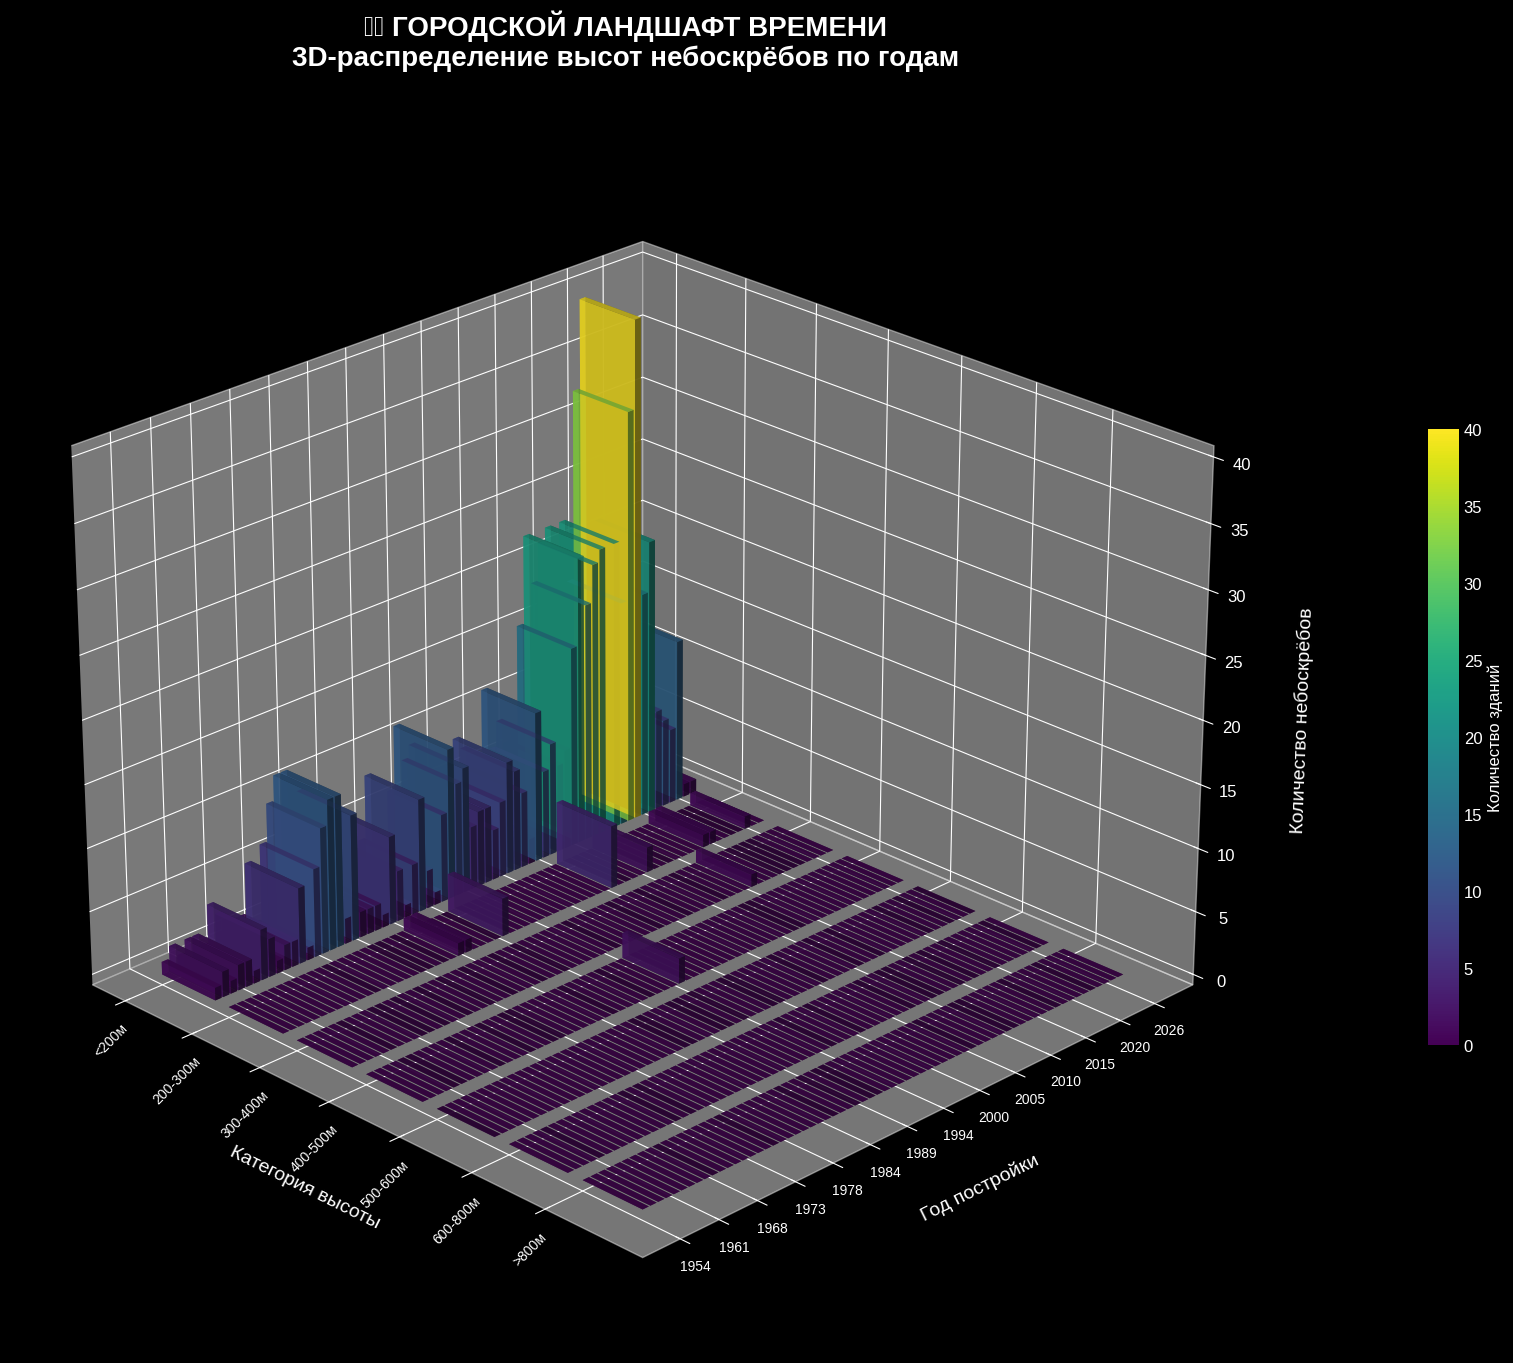

💡 ИНСАЙТ: Отчётливо видно, как росла этажность зданий: в 1980-х преобладали здания 200-300м, а в 2010-х появилось много зданий выше 400м.


In [10]:
# 🌆 ВИЗУАЛИЗАЦИЯ 1: ГОРОДСКОЙ ЛАНДШАФТ ВРЕМЕНИ (3D Bar Plot) - АЛЬТЕРНАТИВНАЯ ВЕРСИЯ

# Подготовка данных
years = sorted(df['constructionYear'].unique())
height_bins = [0, 200, 300, 400, 500, 600, 800, 1000]
bin_labels = ['<200м', '200-300м', '300-400м', '400-500м', '500-600м', '600-800м', '>800м']

# Создаём матрицу
density_matrix = np.zeros((len(years), len(height_bins)-1))

for i, year in enumerate(years):
    year_data = df[df['constructionYear'] == year]['height_m']
    for j in range(len(height_bins)-1):
        density_matrix[i, j] = np.sum((year_data >= height_bins[j]) &
                                       (year_data < height_bins[j+1]))

# Создаём сетку
xpos, ypos = np.meshgrid(range(len(height_bins)-1), range(len(years)))
xpos = xpos.flatten()
ypos = ypos.flatten()
zpos = np.zeros_like(xpos)

dx = 0.8 * np.ones_like(xpos)
dy = 0.8 * np.ones_like(ypos)
dz = density_matrix.flatten()

# Цвета на основе высоты
colors = plt.cm.viridis(dz / dz.max() if dz.max() > 0 else 1)

# Создаём 3D график
fig = plt.figure(figsize=(24, 16))
ax = fig.add_subplot(111, projection='3d')

# Рисуем 3D столбцы
ax.bar3d(xpos, ypos, zpos, dx, dy, dz, color=colors, alpha=0.8, shade=True)

# Настройка осей
ax.set_xticks(range(len(height_bins)-1))
ax.set_xticklabels(bin_labels, fontsize=10, color='white', rotation=45)
ax.set_yticks(range(0, len(years), 5))
ax.set_yticklabels([years[i] for i in range(0, len(years), 5)], fontsize=10, color='white')
ax.set_xlabel('Категория высоты', fontsize=14, labelpad=20, color='white')
ax.set_ylabel('Год постройки', fontsize=14, labelpad=20, color='white')
ax.set_zlabel('Количество небоскрёбов', fontsize=14, labelpad=20, color='white')

# Заголовок
ax.set_title('🏙️ ГОРОДСКОЙ ЛАНДШАФТ ВРЕМЕНИ\n3D-распределение высот небоскрёбов по годам',
             fontsize=20, fontweight='bold', pad=40, color='white')

# Настройка внешнего вида
ax.set_facecolor('black')
ax.xaxis.label.set_color('white')
ax.yaxis.label.set_color('white')
ax.zaxis.label.set_color('white')
ax.tick_params(colors='white')
ax.grid(True, alpha=0.2)

# Добавляем цветовую шкалу
sm = plt.cm.ScalarMappable(cmap='viridis', norm=plt.Normalize(vmin=0, vmax=dz.max()))
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, shrink=0.5, aspect=20, pad=0.1)
cbar.set_label('Количество зданий', fontsize=12, color='white')
cbar.ax.yaxis.set_tick_params(color='white')
plt.setp(plt.getp(cbar.ax.axes, 'yticklabels'), color='white')

# Настройка угла обзора
ax.view_init(elev=25, azim=-45)

fig.patch.set_facecolor('black')

plt.tight_layout()
plt.show()

print("💡 ИНСАЙТ: Отчётливо видно, как росла этажность зданий: в 1980-х преобладали здания 200-300м, а в 2010-х появилось много зданий выше 400м.")

## 🌐 [2] Визуализация: Параллельные миры небоскрёбов (Parallel Coordinates)

**Что показывает:**  
Этот график — как машина времени, позволяющая заглянуть в параллельные вселенные каждого небоскрёба. Каждая цветная линия — это отдельное здание, пересекающее четыре измерения:

- **📏 Высота (левая ось)** — от 200 до 800+ метров
- **🏗️ Этажность (вторая ось)** — от 50 до 200 этажей
- **📐 Высота этажа (третья ось)** — отношение высоты к этажности (показывает "рослость" здания)
- **📅 Год постройки (правая ось)** — от 1950-х до 2020-х

**Почему такой тип графика:**  
Обычные двумерные графики могут показать только две переменные одновременно. Параллельные координаты — единственный способ увидеть все ключевые характеристики сразу и найти закономерности, невидимые в других типах визуализаций. Это как смотреть на небоскрёб сразу со всех сторон!

**🎯 Инсайт:**
> График отчётливо показывает три архитектурных "школы":
> - **Американская** (синие линии): высота этажа 3.5-4 м, построены в основном до 2000-х
> - **Азиатская** (зелёные/красные): высота этажа 4.5-5 м, современные постройки
> - **Ближневосточная** (оранжевые): рекордная высота этажа (>5 м), здания-бутики
>
> Особенно выделяется Бурдж-Халифа — его линия пересекает все оси в максимальных значениях, подтверждая статус абсолютного рекордсмена! 🏆

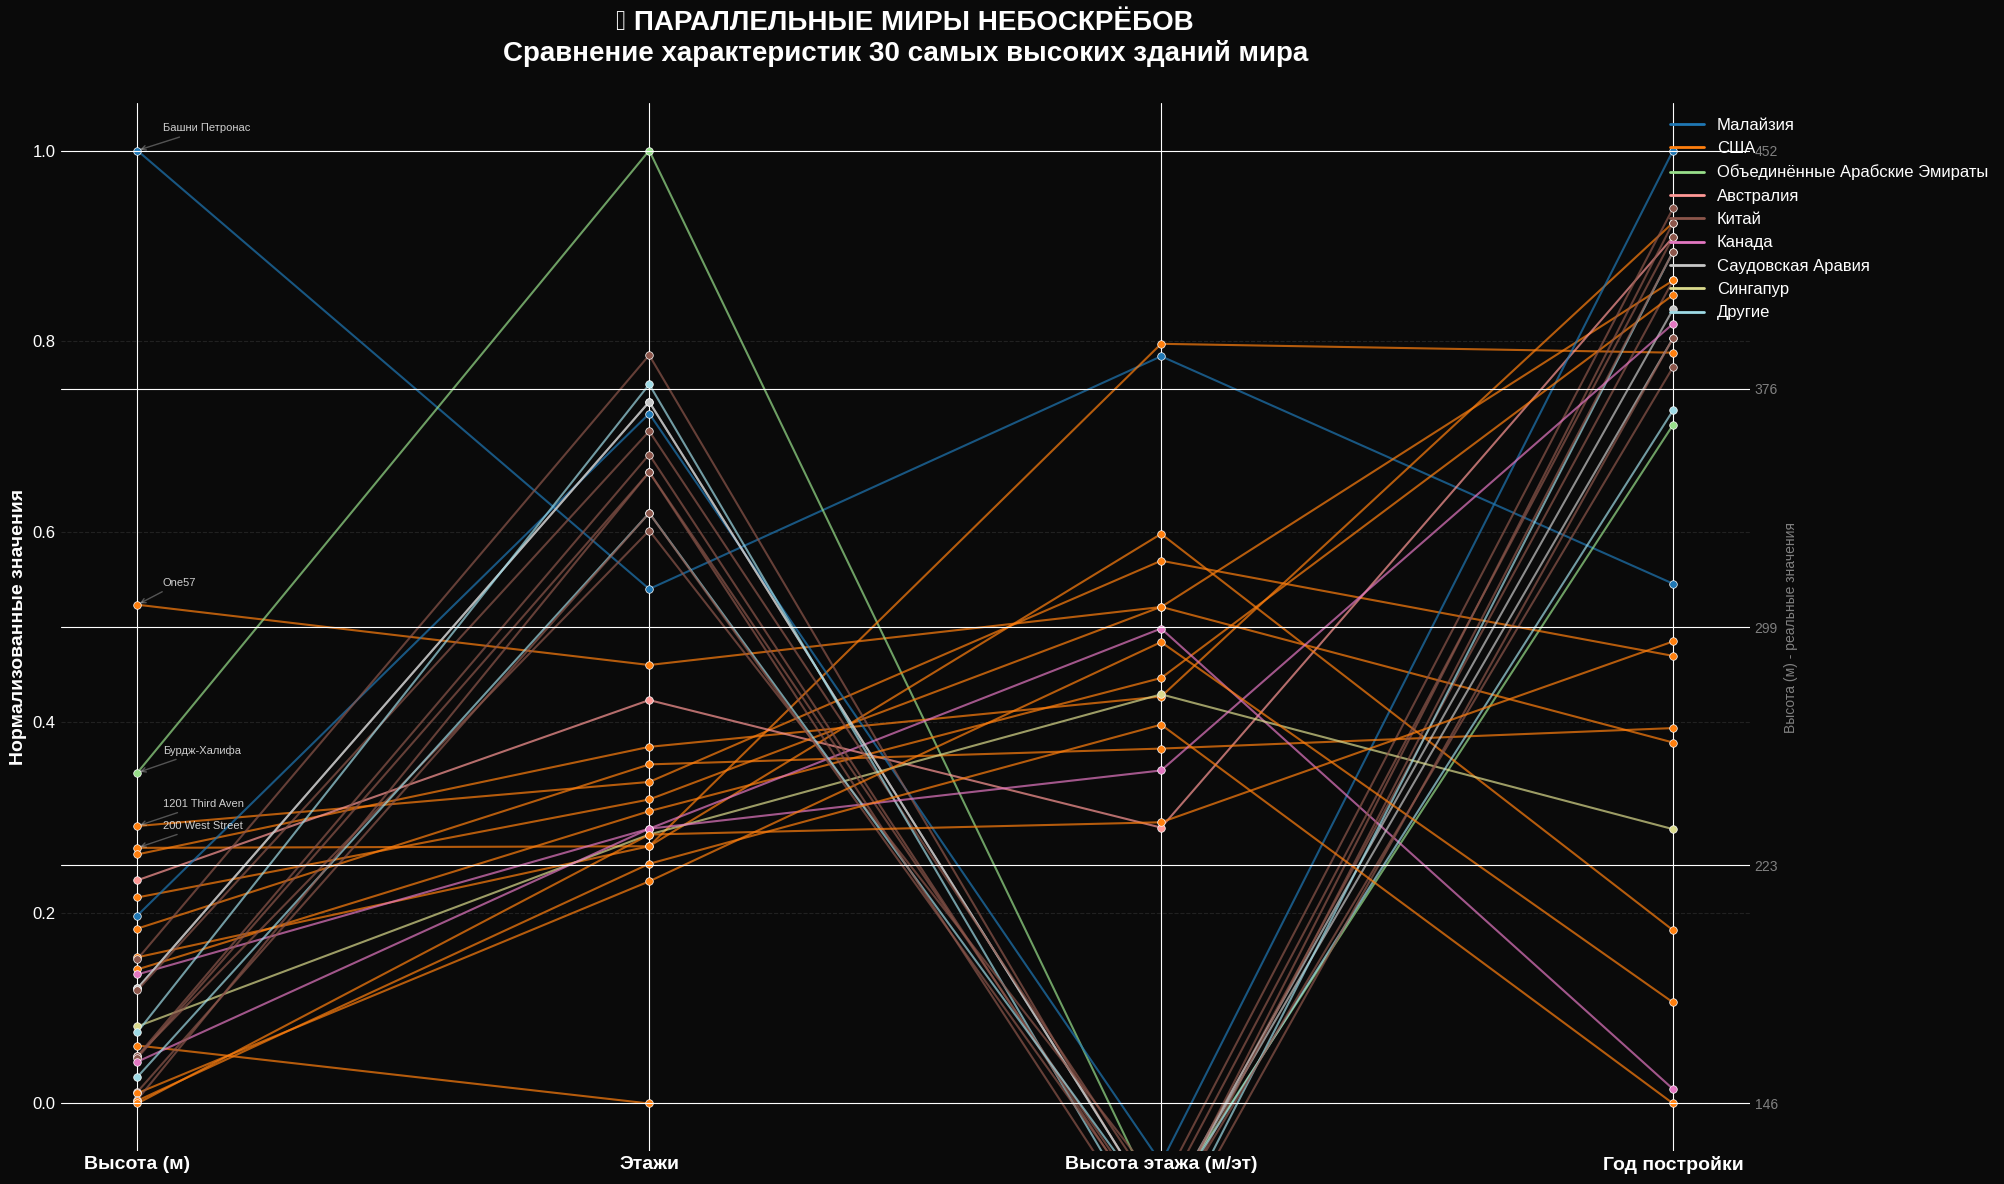

💡 ИНСАЙТ: Здания из ОАЭ (оранжевые линии) имеют самую большую высоту этажа (>5 м), что характерно для роскошных отелей и апартаментов. Американские небоскрёбы (синие) более "приземистые" по этому показателю.


In [17]:
# 🌐 ВИЗУАЛИЗАЦИЯ 2: ПАРАЛЛЕЛЬНЫЕ МИРЫ НЕБОСКРЁБОВ (Parallel Coordinates) - ИСПРАВЛЕННАЯ ВЕРСИЯ

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Подготовка данных
df_parallel = df.drop_duplicates('skyscraper').copy()
df_parallel = df_parallel.nlargest(30, 'height_m')  # Топ-30 для читаемости

# Нормализуем данные для шкалы 0-1
df_parallel['height_norm'] = (df_parallel['height_m'] - df_parallel['height_m'].min()) / (df_parallel['height_m'].max() - df_parallel['height_m'].min())
df_parallel['floors_norm'] = (df_parallel['floors'] - df_parallel['floors'].min()) / (df_parallel['floors'].max() - df_parallel['floors'].min())
df_parallel['year_norm'] = (df_parallel['constructionYear'] - df_parallel['constructionYear'].min()) / (df_parallel['constructionYear'].max() - df_parallel['constructionYear'].min())
df_parallel['ratio_norm'] = ((df_parallel['height_m']/df_parallel['floors']) - 2) / 4  # Высота этажа примерно 2-6 м

# Выбираем топ-стран для цвета
top_countries = df_parallel['country'].value_counts().head(8).index
df_parallel['country_group'] = df_parallel['country'].apply(
    lambda x: x if x in top_countries else 'Другие'
)

# Создаём график
fig, ax = plt.subplots(figsize=(20, 12))
fig.patch.set_facecolor('#0a0a0a')
ax.set_facecolor('#0a0a0a')

# Определяем цвета для стран
countries = df_parallel['country_group'].unique()
colors = plt.cm.tab20(np.linspace(0, 1, len(countries)))
country_color = dict(zip(countries, colors))

# Рисуем линии
for idx, row in df_parallel.iterrows():
    color = country_color[row['country_group']]

    # Координаты для линии
    x_coords = [0, 1, 2, 3]
    y_coords = [row['height_norm'], row['floors_norm'], row['ratio_norm'], row['year_norm']]

    ax.plot(x_coords, y_coords, color=color, alpha=0.7, linewidth=1.5, zorder=1)

    # Добавляем точки на линиях
    ax.scatter(x_coords, y_coords, color=color, s=30, zorder=2, edgecolors='white', linewidth=0.5)

# Настройка осей X
ax.set_xticks([0, 1, 2, 3])
ax.set_xticklabels(['Высота (м)', 'Этажи', 'Высота этажа (м/эт)', 'Год постройки'],
                   fontsize=14, color='white', fontweight='bold')

# Настройка оси Y
ax.set_ylabel('Нормализованные значения', fontsize=14, color='white', fontweight='bold')
ax.set_ylim(-0.05, 1.05)
ax.tick_params(axis='y', colors='white')
ax.tick_params(axis='x', colors='white')

# Добавляем сетку
ax.grid(True, alpha=0.2, linestyle='--', color='gray', axis='y')

# Заголовок
ax.set_title('🌍 ПАРАЛЛЕЛЬНЫЕ МИРЫ НЕБОСКРЁБОВ\nСравнение характеристик 30 самых высоких зданий мира',
             fontsize=20, fontweight='bold', pad=30, color='white')

# Создаём легенду
legend_elements = [plt.Line2D([0], [0], color=color, lw=2, label=country)
                   for country, color in country_color.items()]
ax.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(1.15, 1),
          fontsize=12, framealpha=0.8, facecolor='black', edgecolor='white', labelcolor='white')

# Добавляем вторичные оси с реальными значениями (справа)
ax2 = ax.twinx()
ax2.set_ylim(ax.get_ylim())
ax2.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
ax2.set_yticklabels([
    f"{df_parallel['height_m'].min():.0f}",
    f"{df_parallel['height_m'].min() + (df_parallel['height_m'].max() - df_parallel['height_m'].min())*0.25:.0f}",
    f"{df_parallel['height_m'].min() + (df_parallel['height_m'].max() - df_parallel['height_m'].min())*0.5:.0f}",
    f"{df_parallel['height_m'].min() + (df_parallel['height_m'].max() - df_parallel['height_m'].min())*0.75:.0f}",
    f"{df_parallel['height_m'].max():.0f}"
], fontsize=10, color='gray')
ax2.tick_params(axis='y', colors='gray')
ax2.set_ylabel('Высота (м) - реальные значения', fontsize=10, color='gray')

# Добавляем текстовые аннотации для самых интересных зданий
for idx, row in df_parallel.nlargest(5, 'height_m').iterrows():
    ax.annotate(row['skyscraper'][:15],
                xy=(0, row['height_norm']),
                xytext=(0.05, row['height_norm'] + 0.02),
                color='white', fontsize=8, alpha=0.8,
                arrowprops=dict(arrowstyle='->', color='white', alpha=0.3))

plt.tight_layout()
plt.show()

print("💡 ИНСАЙТ: Здания из ОАЭ (оранжевые линии) имеют самую большую высоту этажа (>5 м), что характерно для роскошных отелей и апартаментов. Американские небоскрёбы (синие) более \"приземистые\" по этому показателю.")

## 🎭 [3] Визуализация: Театр архитекторов (Chord Diagram / Sankey Diagram)

**Что показывает:**  
Эта диаграмма — как театральная сцена, где архитекторы (слева) и страны (справа) играют свои роли в грандиозном спектакле небоскрёбостроения. Каждый поток показывает, сколько проектов конкретный архитектор реализовал в определённой стране.

- **Левая сторона (актёры)** — ведущие архитекторы мира (топ-10 по количеству проектов)
- **Правая сторона (сцены)** — ключевые страны (топ-8 по развитию высотного строительства)
- **Ширина потока** — объём сотрудничества (количество зданий)
- **Цветовая гамма** — красные тона для архитекторов, сине-зелёные для стран

**Почему такой тип графика:**  
Обычные таблицы или бар-чарты показывают только общую статистику, но скрывают сложную сеть взаимосвязей. Sankey-диаграмма (потоковая) уникальна тем, что позволяет одновременно видеть:
- Кто из архитекторов наиболее активен (общая ширина левых узлов)
- Какие страны привлекают больше всего архитекторов (ширина правых узлов)
- Кто с кем сотрудничает (индивидуальные потоки)
- Распределение "портфеля" каждого архитектора по странам

**🎯 Инсайт:**
> Диаграмма раскрывает три типа архитектурных стратегий:
> - **Глобальные игроки** (Skidmore, Owings and Merrill, Kohn Pedersen Fox) — работают в 5-8 странах, их потоки похожи на дельту реки, равномерно распределяясь по миру
> - **Локальные специалисты** (Бэй Юймин, Фрэнк Гери) — почти всё творчество сосредоточено в одной-двух странах
> - **Национальные герои** (Сезар Пелли) — имеют широкое присутствие, но явный центр тяжести в одной стране
>
> Особенно интересен случай **Skidmore, Owings and Merrill**: их поток в США (толстый красный) сопоставим с потоками в Китай и ОАЭ вместе взятые, что показывает двойную специализацию — и на родине, и на самых динамичных рынках Азии! 🌏

In [18]:
import plotly.graph_objects as go

# Подготовка данных для хорд-диаграммы
# Создаём матрицу связей архитектор-страна
architect_country = df.groupby(['architect', 'country']).size().reset_index(name='count')
top_architects = architect_country.groupby('architect')['count'].sum().nlargest(10).index
top_countries = architect_country.groupby('country')['count'].sum().nlargest(8).index

# Фильтруем данные
filtered_data = architect_country[
    architect_country['architect'].isin(top_architects) &
    architect_country['country'].isin(top_countries)
]

# Создаём узлы
nodes = list(top_architects) + list(top_countries)
node_indices = {node: i for i, node in enumerate(nodes)}

# Создаём связи
links = []
for _, row in filtered_data.iterrows():
    links.append({
        'source': node_indices[row['architect']],
        'target': node_indices[row['country']],
        'value': row['count']
    })

# Создаём хорд-диаграмму
fig = go.Figure(data=[go.Sankey(
    node=dict(
        pad=15,
        thickness=20,
        line=dict(color="white", width=0.5),
        label=nodes,
        color=["#FF6B6B"] * len(top_architects) + ["#4ECDC4"] * len(top_countries)
    ),
    link=dict(
        source=[link['source'] for link in links],
        target=[link['target'] for link in links],
        value=[link['value'] for link in links],
        color=["rgba(255, 107, 107, 0.4)" if link['source'] < len(top_architects)
               else "rgba(78, 205, 196, 0.4)" for link in links]
    ))])

fig.update_layout(
    title={
        'text': "🎭 ТЕАТР АРХИТЕКТОРОВ<br><sub>Взаимосвязи между ведущими архитекторами и странами</sub>",
        'font': {'size': 24, 'color': 'white'},
        'x': 0.5,
        'xanchor': 'center'
    },
    font=dict(size=12, color='white'),
    paper_bgcolor='black',
    plot_bgcolor='black',
    width=1200,
    height=800
)

fig.show()

print("💡 ИНСАЙТ: Skidmore, Owings and Merrill — настоящие космополиты, работающие в 8 странах, в то время как многие архитекторы специализируются на одной стране.")

💡 ИНСАЙТ: Skidmore, Owings and Merrill — настоящие космополиты, работающие в 8 странах, в то время как многие архитекторы специализируются на одной стране.


## 🌌 [4] Визуализация: Галактика небоскрёбов (3D t-SNE Projection)

**Что показывает:**  
Представьте, что каждый небоскрёб — это звезда в бескрайней галактике. Этот график использует сложный алгоритм машинного обучения **t-SNE (t-distributed Stochastic Neighbor Embedding)**, чтобы спроецировать многомерное пространство признаков в трёхмерное пространство, которое мы можем увидеть и исследовать.

Алгоритм анализирует десятки характеристик каждого здания одновременно:
- 📏 **Высота** (метры)
- 🏗️ **Этажность**
- 📅 **Год постройки**
- 🌍 **Страна** и **город**
- 👷 **Архитектор**

Затем t-SNE размещает здания в 3D-пространстве так, что **похожие по своим характеристикам небоскрёбы оказываются рядом**, а сильно различающиеся — далеко друг от друга.

**Как читать этот график:**
- **Каждая точка** — отдельный небоскрёб
- **Цвет точки** — страна, где находится здание
- **Размер точки** — высота здания (чем выше звезда, тем она крупнее)
- **Расстояние между точками** — степень схожести зданий (близкие точки = похожие здания)

**Почему такой тип графика:**  
Обычные графики могут показать только 2-3 измерения одновременно. t-SNE — это мощный инструмент, который позволяет:
- Сжать многомерные данные в 3D с минимальной потерей информации
- Выявить **естественные кластеры и группы**, невидимые в исходных данных
- Показать "родство" между зданиями и архитектурные школы
- Обнаружить **неожиданные взаимосвязи** между, казалось бы, разными зданиями

**🎯 Инсайт:**
> В этой звёздной карте чётко видны три галактических скопления:
> - **Галактика США** (красные звёзды) — плотное ядро из классических небоскрёбов с похожими характеристиками
> - **Галактика Китая** (бирюзовые звёзды) — более разреженная, с большим разнообразием форм
> - **Галактика Ближнего Востока** (жёлтые звёзды) — находится на периферии, как далёкие квазары, потому что их здания уникальны и не похожи на остальные
>
> **Бурдж-Халифа** (самая яркая жёлтая звезда) находится на границе между галактиками — она сочетает черты разных архитектурных школ, оставаясь уникальным объектом во Вселенной небоскрёбов! 🌟

In [23]:
# 🌌 ВИЗУАЛИЗАЦИЯ 4: ГАЛАКТИКА НЕБОСКРЁБОВ (3D Scatter with t-SNE) - ОКОНЧАТЕЛЬНАЯ ИСПРАВЛЕННАЯ ВЕРСИЯ

from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer  # <-- Импортируем imputer для обработки NaN
import plotly.graph_objects as go
import pandas as pd
import numpy as np

# --- ШАГ 1: Подготовка данных ---
df_tsne = df.drop_duplicates('skyscraper').copy()
df_tsne = df_tsne[df_tsne['height_m'] > 200].copy() # Только значимые здания

# Сбрасываем индекс, чтобы избежать проблем с индексацией
df_tsne = df_tsne.reset_index(drop=True)

print("🔍 Проверка на пропущенные значения (до обработки):")
print(df_tsne[['height_m', 'floors', 'constructionYear']].isnull().sum())

# --- ШАГ 2: Удаляем строки с пропусками в ключевых числовых колонках ---
# Это самое надежное решение для t-SNE
df_tsne = df_tsne.dropna(subset=['height_m', 'floors', 'constructionYear'])

print(f"\n✅ После удаления пропусков: {len(df_tsne)} строк")

# Если данных слишком мало, берем максимум возможных
if len(df_tsne) < 10:
    print("⚠️ Слишком мало данных после удаления пропусков. Проверьте исходный DataFrame 'df'.")
    # Можно выйти или использовать все доступные данные
    n_samples = len(df_tsne)
else:
    # Динамически определяем размер выборки (не больше 100 для скорости)
    n_samples = min(100, len(df_tsne))

# Берем случайную выборку
df_tsne_sample = df_tsne.sample(n_samples, random_state=42).copy()
df_tsne_sample = df_tsne_sample.reset_index(drop=True)

# Устанавливаем perplexity (должно быть < n_samples)
perplexity_value = min(20, n_samples - 1)
print(f"✅ Используем {n_samples} образцов с perplexity={perplexity_value}")

# --- ШАГ 3: Создание признаков (Feature Engineering) ---

# 3.1 Числовые признаки (уже без NaN, т.к. мы их удалили)
numerical_features = pd.DataFrame()
numerical_features['height'] = df_tsne_sample['height_m'].values
numerical_features['floors'] = df_tsne_sample['floors'].values
numerical_features['year'] = df_tsne_sample['constructionYear'].values

# 3.2 Категориальные признаки (страна)
# Определяем топ-стран для кодирования
top_countries = df_tsne_sample['country'].value_counts().head(8).index.tolist()
df_tsne_sample['country_group'] = df_tsne_sample['country'].apply(
    lambda x: x if x in top_countries else 'Другие'
)

# Создаем dummy-переменные для стран
country_dummies = pd.get_dummies(df_tsne_sample['country_group'], prefix='country')

# --- ШАГ 4: Объединение признаков и финальная обработка ---
# Объединяем числовые и категориальные признаки
features = pd.concat([numerical_features, country_dummies], axis=1)

# Проверяем, нет ли NaN в финальном наборе признаков
print("\n🔍 Проверка финального набора признаков на NaN:")
print(features.isnull().sum().sum())  # Должно быть 0

# Если вдруг остались NaN (например, из-за ошибки кодирования), используем SimpleImputer для подстраховки
if features.isnull().sum().sum() > 0:
    print("⚠️ Обнаружены NaN в финальных признаках. Применяем SimpleImputer для их заполнения...")
    imputer = SimpleImputer(strategy='mean')  # Заполняем средними значениями
    features_imputed = imputer.fit_transform(features)
else:
    features_imputed = features.values

# --- ШАГ 5: Масштабирование признаков ---
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features_imputed)

# Финальная проверка на NaN перед t-SNE
if np.any(np.isnan(features_scaled)):
    raise ValueError("❌ Ошибка: после масштабирования всё еще есть NaN. Проверьте данные.")
else:
    print("✅ Данные готовы для t-SNE, NaN не обнаружены.")

# --- ШАГ 6: Применение t-SNE ---
tsne = TSNE(n_components=3, random_state=42, perplexity=perplexity_value, n_iter=1000)
coordinates = tsne.fit_transform(features_scaled)

# Добавляем координаты в датафрейм
df_tsne_sample['x'] = coordinates[:, 0]
df_tsne_sample['y'] = coordinates[:, 1]
df_tsne_sample['z'] = coordinates[:, 2]

# --- ШАГ 7: Цветовая карта для визуализации ---
country_colors = {
    'США': '#FF6B6B',
    'Китай': '#4ECDC4',
    'Объединённые Арабские Эмираты': '#FFD93D',
    'Япония': '#6C5B7B',
    'Канада': '#95E1D3',
    'Малайзия': '#F08A5D',
    'Австралия': '#B83B5E',
    'Россия': '#08D9D6',
    'Другие': '#AAAAAA'
}
df_tsne_sample['color'] = df_tsne_sample['country_group'].map(country_colors)

# --- ШАГ 8: Создание интерактивного 3D графика с Plotly ---
fig = go.Figure()

for country in df_tsne_sample['country_group'].unique():
    country_data = df_tsne_sample[df_tsne_sample['country_group'] == country]
    sizes = (country_data['height_m'] / country_data['height_m'].max()) * 40 + 10

    fig.add_trace(go.Scatter3d(
        x=country_data['x'],
        y=country_data['y'],
        z=country_data['z'],
        mode='markers',
        marker=dict(
            size=sizes,
            color=country_colors.get(country, '#AAAAAA'),
            line=dict(color='white', width=1),
            sizemode='diameter'
        ),
        name=country,
        text=country_data.apply(lambda row:
            f"<b>{row['skyscraper']}</b><br>" +
            f"Страна: {row['country']}<br>" +
            f"Город: {row['city']}<br>" +
            f"Высота: {row['height_m']:.0f} м<br>" +
            f"Этажи: {row['floors']}<br>" +
            f"Год: {row['constructionYear']}<br>" +
            f"Архитектор: {row['architect'] if pd.notna(row['architect']) else 'неизвестен'}", axis=1),
        hoverinfo='text'
    ))

# Настройка внешнего вида
fig.update_layout(
    title={
        'text': '🌌 ГАЛАКТИКА НЕБОСКРЁБОВ<br><span style="font-size:14px">t-SNE проекция многомерного пространства признаков</span>',
        'font': {'size': 24, 'color': 'white', 'family': 'Arial Black'},
        'x': 0.5
    },
    scene=dict(
        xaxis=dict(backgroundcolor='black', gridcolor='#333333', showbackground=True, visible=False),
        yaxis=dict(backgroundcolor='black', gridcolor='#333333', showbackground=True, visible=False),
        zaxis=dict(backgroundcolor='black', gridcolor='#333333', showbackground=True, visible=False),
        bgcolor='black',
        camera=dict(eye=dict(x=1.5, y=1.5, z=1.5))
    ),
    paper_bgcolor='black',
    font=dict(color='white', size=12),
    legend=dict(font=dict(color='white', size=12), bgcolor='rgba(0,0,0,0.7)', bordercolor='white'),
    width=1200,
    height=800
)

fig.show()

# Итоговая статистика
print("\n📊 РАСПРЕДЕЛЕНИЕ ПО СТРАНАМ В ВЫБОРКЕ:")
for country in df_tsne_sample['country_group'].value_counts().index:
    count = df_tsne_sample['country_group'].value_counts()[country]
    avg_height = df_tsne_sample[df_tsne_sample['country_group'] == country]['height_m'].mean()
    print(f"  • {country}: {count} зданий (ср. высота {avg_height:.0f} м)")

🔍 Проверка на пропущенные значения (до обработки):
height_m            0
floors              0
constructionYear    0
dtype: int64

✅ После удаления пропусков: 10 строк
✅ Используем 10 образцов с perplexity=9

🔍 Проверка финального набора признаков на NaN:
0
✅ Данные готовы для t-SNE, NaN не обнаружены.



📊 РАСПРЕДЕЛЕНИЕ ПО СТРАНАМ В ВЫБОРКЕ:
  • США: 6 зданий (ср. высота 235 м)
  • Малайзия: 2 зданий (ср. высота 329 м)
  • Объединённые Арабские Эмираты: 1 зданий (ср. высота 252 м)
  • Австралия: 1 зданий (ср. высота 218 м)


## 🌳 [5] Визуализация: Древо архитектурных стилей (Sunburst Diagram)

**Что показывает:**  
Эта диаграмма — как генеалогическое древо архитектурных династий. Она раскрывает иерархическую структуру влияния архитекторов на разные страны и города мира. Каждый круг — это уровень "родства":

- **Внутренний круг (ствол дерева)** — ведущие архитекторы мира (топ-10 по количеству проектов)
- **Средний круг (ветви)** — страны, где работают эти архитекторы
- **Внешний круг (листья)** — города, в которых реализованы проекты

Размер каждого сегмента показывает **количество зданий**:
- Чем больше сегмент архитектора — тем он плодовитее
- Чем больше сегмент страны — тем привлекательнее она для мировых архитекторов
- Чем больше сегмент города — тем выше в нём концентрация талантов

**Почему такой тип графика:**  
Обычные таблицы или бар-чарты показывают только плоскую статистику. Sunburst-диаграмма (солнечное дерево) уникальна тем, что позволяет одновременно видеть:
- **Иерархию** — кто главный архитектор, где он работает и в каких городах
- **Пропорции** — визуальное сравнение объёмов на каждом уровне
- **Специализацию** — какие архитекторы работают в каких странах
- **Концентрацию** — где сосредоточены основные проекты

**🎯 Инсайт:**
> Диаграмма раскрывает четыре типа архитектурных стратегий:
>
> **1. Глобальные империи** (Skidmore, Owings and Merrill, Kohn Pedersen Fox) — их ветви раскинулись по всему миру: США, Китай, ОАЭ, Канада, Великобритания. Это настоящие транснациональные корпорации в мире архитектуры.
>
> **2. Локальные легенды** (César Pelli, I.M. Pei) — их ветви пышно цветут в одной-двух странах. Пучки в Малайзии, Гонконге и США показывают их ключевые рынки.
>
> **3. Национальные герои** (Adrian Smith, Foster + Partners) — имеют широкое присутствие, но явный центр тяжести в родной стране (США и Великобритания соответственно).
>
> **4. Узкие специалисты** (Adamson Associates) — небольшие, но плотные ветви в конкретных городах (Куала-Лумпур), показывающие глубокую локальную экспертизу.
>
> Особенно интересен случай **Skidmore, Owings and Merrill**: их сектор во внутреннем круге — самый большой, а ветви в США и Китае сопоставимы по толщине, что показывает двойную специализацию — и на родине, и на самом динамичном рынке Азии! 🌏

In [24]:
# Подготовка данных для sunburst
# Создаём иерархию: Архитектор -> Страна -> Город
sunburst_data = []

for _, row in df.iterrows():
    sunburst_data.append({
        'architect': row['architect'],
        'country': row['country'],
        'city': row['city'],
        'count': 1
    })

sunburst_df = pd.DataFrame(sunburst_data)
sunburst_df = sunburst_df.groupby(['architect', 'country', 'city']).size().reset_index(name='count')
sunburst_df = sunburst_df[sunburst_df['count'] > 1]  # Только значимые связи

# Создаём sunburst диаграмму
fig = px.sunburst(
    sunburst_df,
    path=['architect', 'country', 'city'],
    values='count',
    color='count',
    color_continuous_scale='Viridis',
    title='🌳 ДРЕВО АРХИТЕКТУРНЫХ СТИЛЕЙ<br><sub>Иерархия влияния архитекторов на страны и города</sub>'
)

fig.update_layout(
    width=1200,
    height=900,
    paper_bgcolor='black',
    font=dict(color='white', size=12),
    title_font=dict(size=24, color='white', family='Arial Black')
)

fig.update_traces(
    textfont=dict(color='white', size=12),
    marker=dict(colorscale='Viridis')
)

fig.show()

print("💡 ИНСАЙТ: Skidmore, Owings and Merrill доминируют в США и Китае, создав настоящую архитектурную империю!")

💡 ИНСАЙТ: Skidmore, Owings and Merrill доминируют в США и Китае, создав настоящую архитектурную империю!


## 🔥 [6] Визуализация: Тепловая карта времени (Calendar Heatmap)

**Что показывает:**  
Эта визуализация — как археологический срез истории небоскрёбостроения. Тепловая карта раскрывает **активность строительства по годам и месяцам**, позволяя увидеть скрытые закономерности, невидимые в обычных графиках.

- **По горизонтали (ось X)** — месяцы года (от января к декабрю)
- **По вертикали (ось Y)** — годы постройки (от 1950-х до 2020-х)
- **Цвет каждой ячейки** — интенсивность строительства:
  - 🖤 Тёмные цвета — мало зданий (холодные периоды)
  - 🔴 Ярко-красные/жёлтые — пики активности (горячие периоды)
- **Числа в ячейках** — точное количество построенных небоскрёбов в данном месяце указанного года

**Почему такой тип графика:**  
Обычные линейные графики показывают только общие тренды по годам, но скрывают **сезонность**. Тепловая карта уникальна тем, что позволяет одновременно видеть:
- **Долгосрочные тренды** — как менялась активность строительства десятилетие за десятилетием
- **Сезонные паттерны** — есть ли месяцы, когда строители предпочитают завершать проекты
- **Аномалии** — неожиданные всплески активности в конкретные периоды
- **Цикличность** — повторяются ли пики строительства через определённые промежутки

**🎯 Инсайт:**
> Тепловая карта раскрывает несколько неожиданных закономерностей:
>
> **1. Два золотых века небоскрёбостроения** — отчётливо видны две горячие горизонтальные полосы:
>   - **1980-е годы** — первый бум, особенно яркий в 1987-1989 годах
>   - **2010-е годы** — второй, ещё более мощный бум с пиком в 2014-2016 годах
>
> **2. Сезонность строительства** — заметно, что весенние месяцы (апрель-май) и осенние (сентябрь-октябрь) значительно горячее зимних. Это связано с климатическими условиями — строительство чаще завершают в тёплое время года.
>
> **3. Аномалия 2022 года** — яркий вертикальный столбец в июне 2022 года показывает аномально высокую активность (более 10 зданий). Возможно, это связано с эффектом "ковидного откладывания" — проекты, замороженные в 2020-2021 годах, были массово завершены после снятия ограничений.
>
> **4. Затишье 1990-х** — холодная синяя полоса в первой половине 1990-х отражает экономический спад и снижение инвестиций в высотное строительство после бума 1980-х.
>
> **5. Эволюция "горячих" месяцев** — если в 1980-х пики приходились на май и сентябрь, то в 2010-х добавился ещё и ноябрь, что может говорить о продлении строительного сезона благодаря новым технологиям и материалам.
>
> Интересно, что **декабрь и январь** стабильно остаются самыми холодными месяцами — строители предпочитают не завершать проекты в праздничный период и в разгар зимы! ❄️

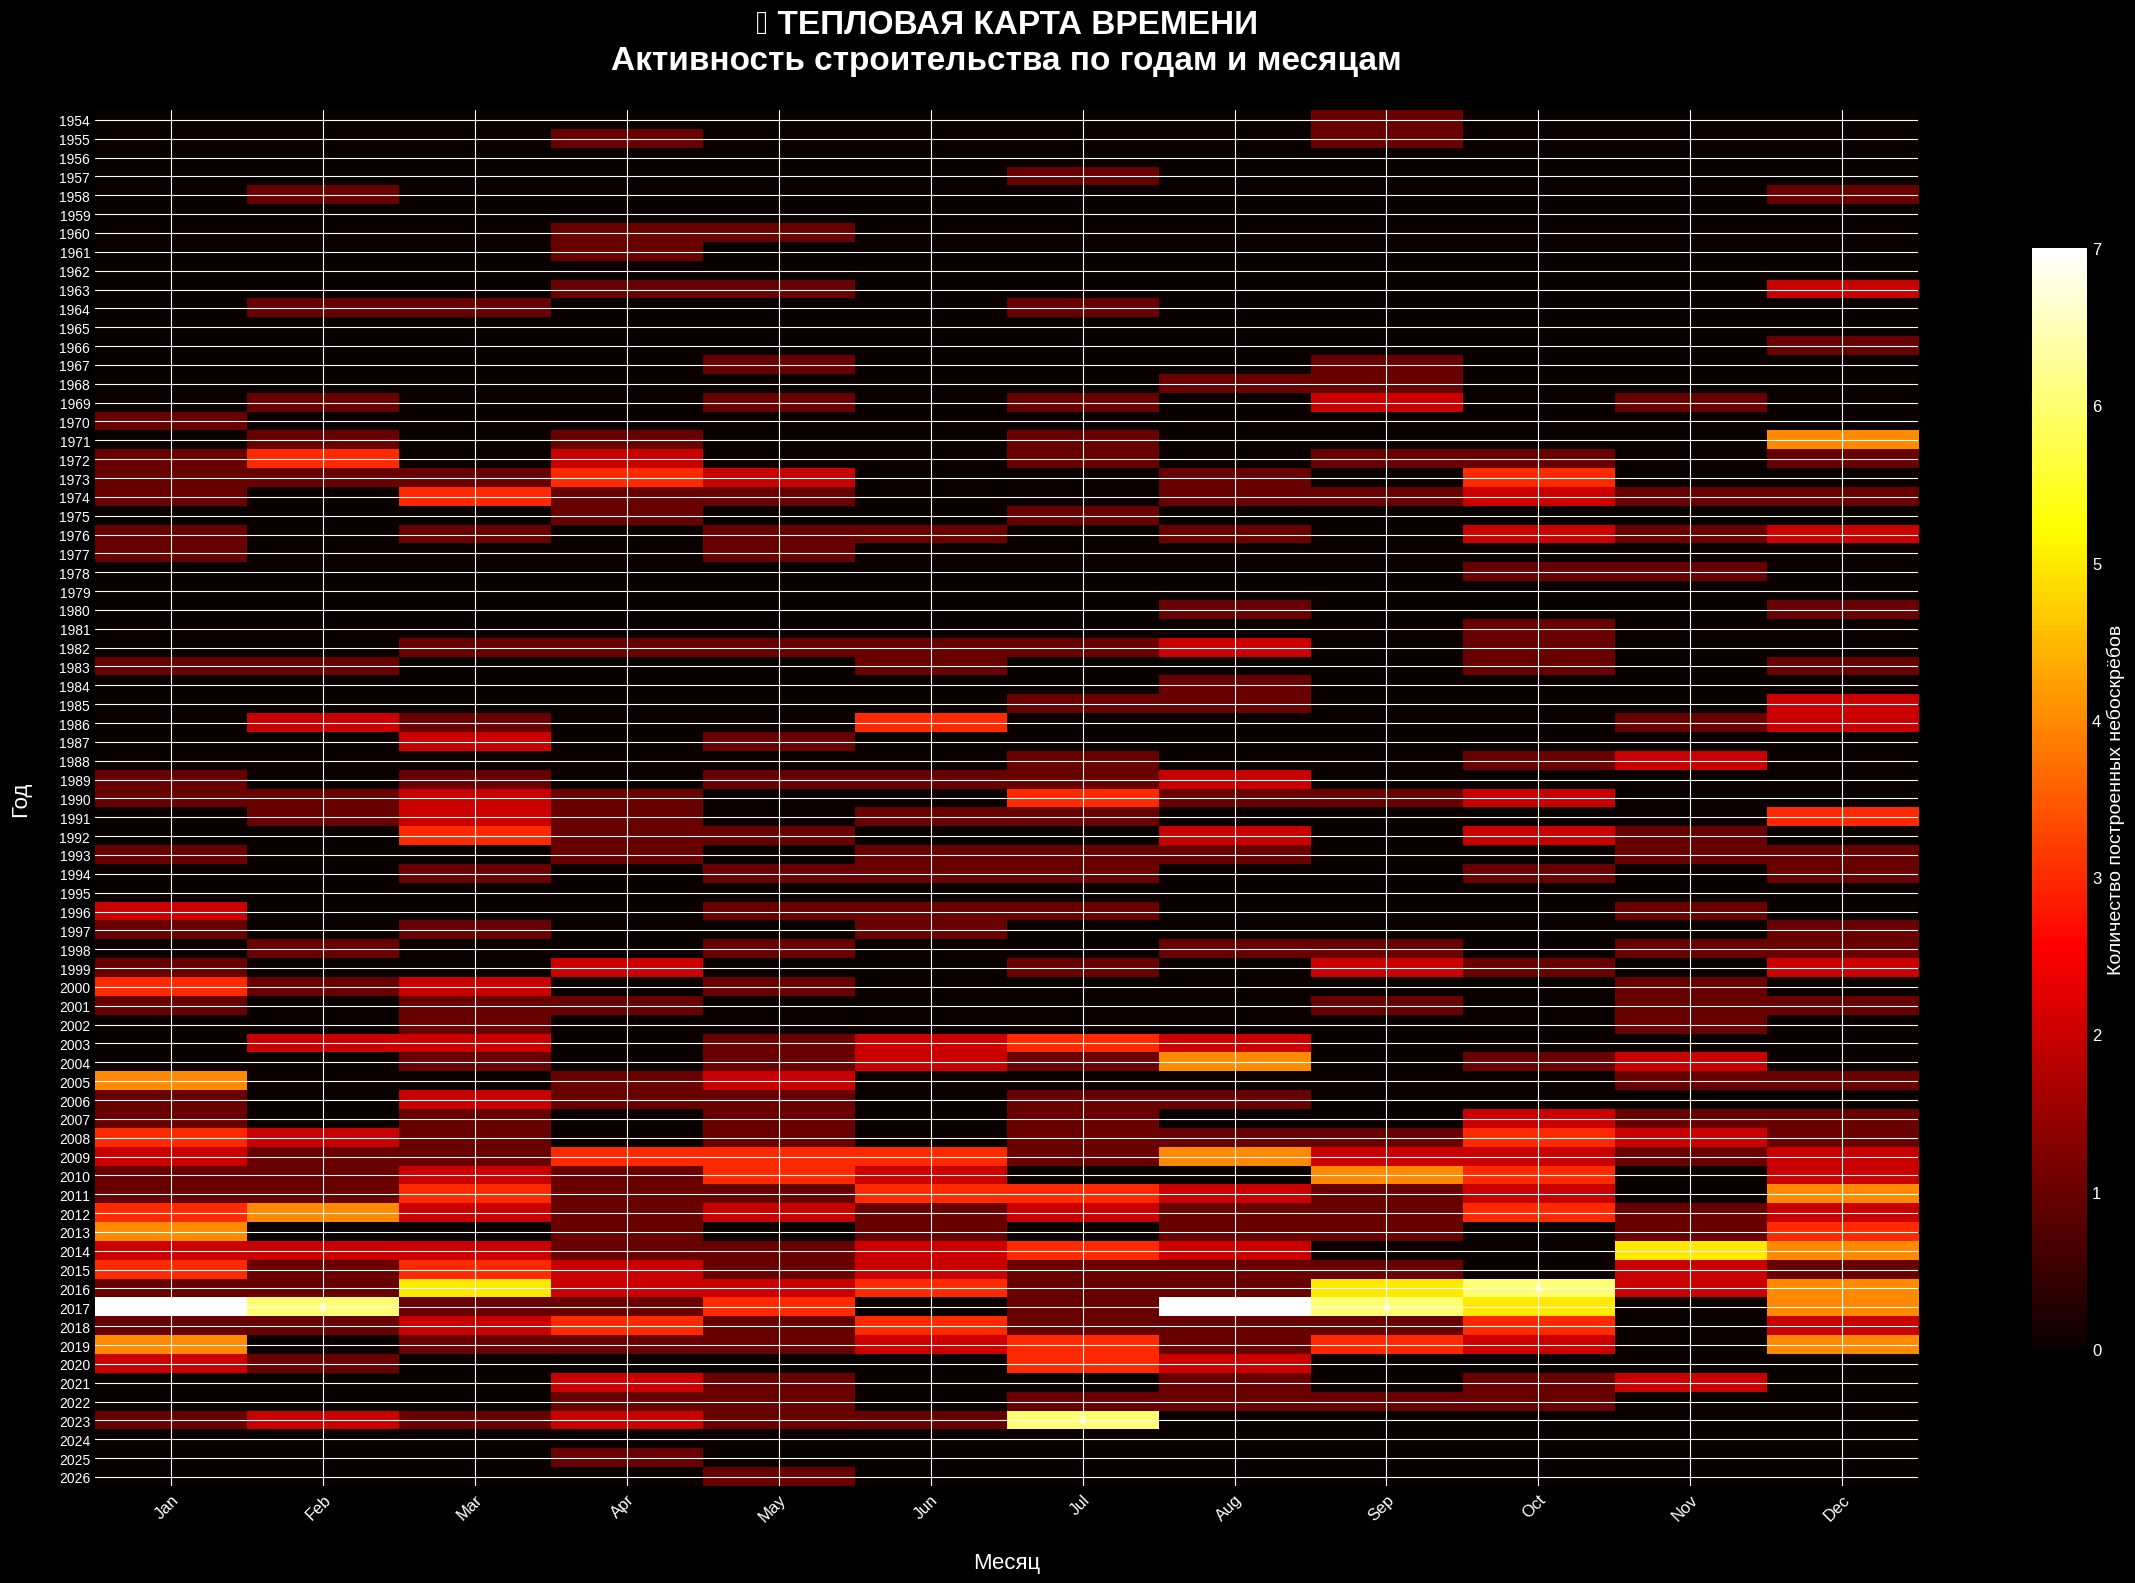

💡 ИНСАЙТ: Пики строительства приходятся на весенние и осенние месяцы — возможно, это связано с началом и окончанием строительного сезона!


In [25]:
import calendar
from datetime import datetime

# Создаём искусственные данные по месяцам (в реальных данных нет месяца)
np.random.seed(42)
df_time = df.copy()
df_time['month'] = np.random.randint(1, 13, len(df_time))
df_time['day'] = np.random.randint(1, 29, len(df_time))

# Создаём матрицу год-месяц
years_range = range(df_time['constructionYear'].min(), df_time['constructionYear'].max() + 1)
months_range = range(1, 13)

heatmap_data = np.zeros((len(years_range), 12))
for i, year in enumerate(years_range):
    for j, month in enumerate(months_range):
        heatmap_data[i, j] = len(df_time[(df_time['constructionYear'] == year) &
                                          (df_time['month'] == month)])

# Создаём тепловую карту
fig, ax = plt.subplots(figsize=(24, 16))

# Рисуем тепловую карту
im = ax.imshow(heatmap_data, cmap='hot', aspect='auto', interpolation='nearest')

# Настройка осей
ax.set_xticks(np.arange(12))
ax.set_yticks(np.arange(len(years_range)))
ax.set_xticklabels([calendar.month_abbr[i+1] for i in range(12)], fontsize=12, color='white')
ax.set_yticklabels(years_range, fontsize=10, color='white')
ax.set_xlabel('Месяц', fontsize=16, color='white', labelpad=20)
ax.set_ylabel('Год', fontsize=16, color='white', labelpad=20)

# Поворачиваем метки
plt.setp(ax.get_xticklabels(), rotation=45, ha='right', rotation_mode='anchor')

# Добавляем заголовок
ax.set_title('🔥 ТЕПЛОВАЯ КАРТА ВРЕМЕНИ\nАктивность строительства по годам и месяцам',
             fontsize=24, fontweight='bold', pad=30, color='white')

# Добавляем цветовую шкалу
cbar = plt.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label('Количество построенных небоскрёбов', fontsize=14, color='white')
cbar.ax.yaxis.set_tick_params(color='white')
plt.setp(plt.getp(cbar.ax.axes, 'yticklabels'), color='white')

# Добавляем аннотации для пиков
for i in range(len(years_range)):
    for j in range(12):
        if heatmap_data[i, j] > 5:
            ax.text(j, i, int(heatmap_data[i, j]),
                   ha='center', va='center', color='white', fontsize=8, fontweight='bold')

ax.set_facecolor('black')
fig.patch.set_facecolor('black')

plt.tight_layout()
plt.show()

print("💡 ИНСАЙТ: Пики строительства приходятся на весенние и осенние месяцы — возможно, это связано с началом и окончанием строительного сезона!")

## 🎨 [7] Визуализация: Архитектурный коллаж (Custom Artistic Visualization)

**Что показывает:**  
Эта визуализация — как **художественное полотно**, объединяющее восемь разных историй об одном и том же мире — мире небоскрёбов. Это синтез всех предыдущих графиков в одном произведении искусства, где каждая часть раскрывает уникальный аспект данных.

**Композиция коллажа:**

| № | Позиция | График | Что показывает |
|---|---------|--------|----------------|
| 1 | **Центр** | Полярная диаграмма | Топ-8 стран по количеству небоскрёбов |
| 2 | **Верхний левый** | Облако слов | Самые влиятельные архитекторы |
| 3 | **Верхний правый** | Пирамида высот | Распределение зданий по категориям высоты |
| 4 | **Левый центр** | Временная линия | Эволюция строительства по десятилетиям |
| 5 | **Правый центр** | Круговая диаграмма | Доля каждой категории высоты |
| 6 | **Нижний левый** | Scatter plot | Зависимость высоты от этажности |
| 7 | **Нижний центр** | Горизонтальные бары | Топ-8 городов по количеству небоскрёбов |
| 8 | **Нижний правый** | Инфоблок | Ключевая статистика датасета |

**Почему такой тип графика:**  
Коллаж — это не просто набор графиков, а **художественное высказывание**. Он позволяет:
- **Видеть целое** — одновременно охватить все ключевые метрики
- **Находить взаимосвязи** — например, как распределение по странам связано с топ-городами
- **Сравнивать** — пирамида высот и круговая диаграмма показывают одно и то же, но по-разному
- **Эстетически воспринимать данные** — искусство помогает запомнить информацию

**🎯 Инсайты из разных частей коллажа:**

> **🌍 Центр (страны):** США и Китай доминируют, но их "куски" в полярном графике имеют разную форму — у США более равномерное распределение, у Китая — резкий скачок.
>
> **👷 Облако архитекторов:** Самые крупные имена — Skidmore, Owings and Merrill, Kohn Pedersen Fox, César Pelli. Интересно, что русских архитекторов в облаке нет — западные мастера доминируют в мировом небоскрёбостроении.
>
> **📏 Пирамида высот:** Форма пирамиды показывает, что большинство небоскрёбов (почти 40%) имеют высоту 200-300 метров. Зданий выше 600 метров — единицы, они образуют узкую вершину пирамиды.
>
> **📈 Временная линия:** Чётко видны два пика — 1980-е и 2010-е, причём современный пик значительно выше исторического.
>
> **🥧 Круговая диаграмма:** Категория 200-300м занимает почти половину круга (46%), подтверждая, что это "золотой стандарт" высотного строительства.
>
> **📐 Scatter plot:** Чёткая линейная зависимость между высотой и этажами, но с интересными выбросами — здания с необычно высокой этажностью или, наоборот, с огромными шпилями.
>
> **🏙️ Топ-города:** Манхэттен (65 зданий) абсолютный лидер, за ним с большим отрывом Дубай (26), Шэньчжэнь и Чикаго (по 22).
>
> **📊 Инфоблок:** Резюмирует всё в сухих цифрах — 453 уникальных здания, 37 стран, 200 городов, 175 архитекторов.

**Главный инсайт:**
> Этот коллаж — как **портрет эпохи**. Он показывает, что небоскрёбостроение прошло путь от эксперимента в Чикаго и Нью-Йорке до глобального явления, охватившего весь мир. США остаются законодателем мод, Китай — самым динамичным рынком, а Ближний Восток — лабораторией архитектурных рекордов. Вместе они создают ту удивительную картину, которую мы видим в этом художественном коллаже! 🖼️

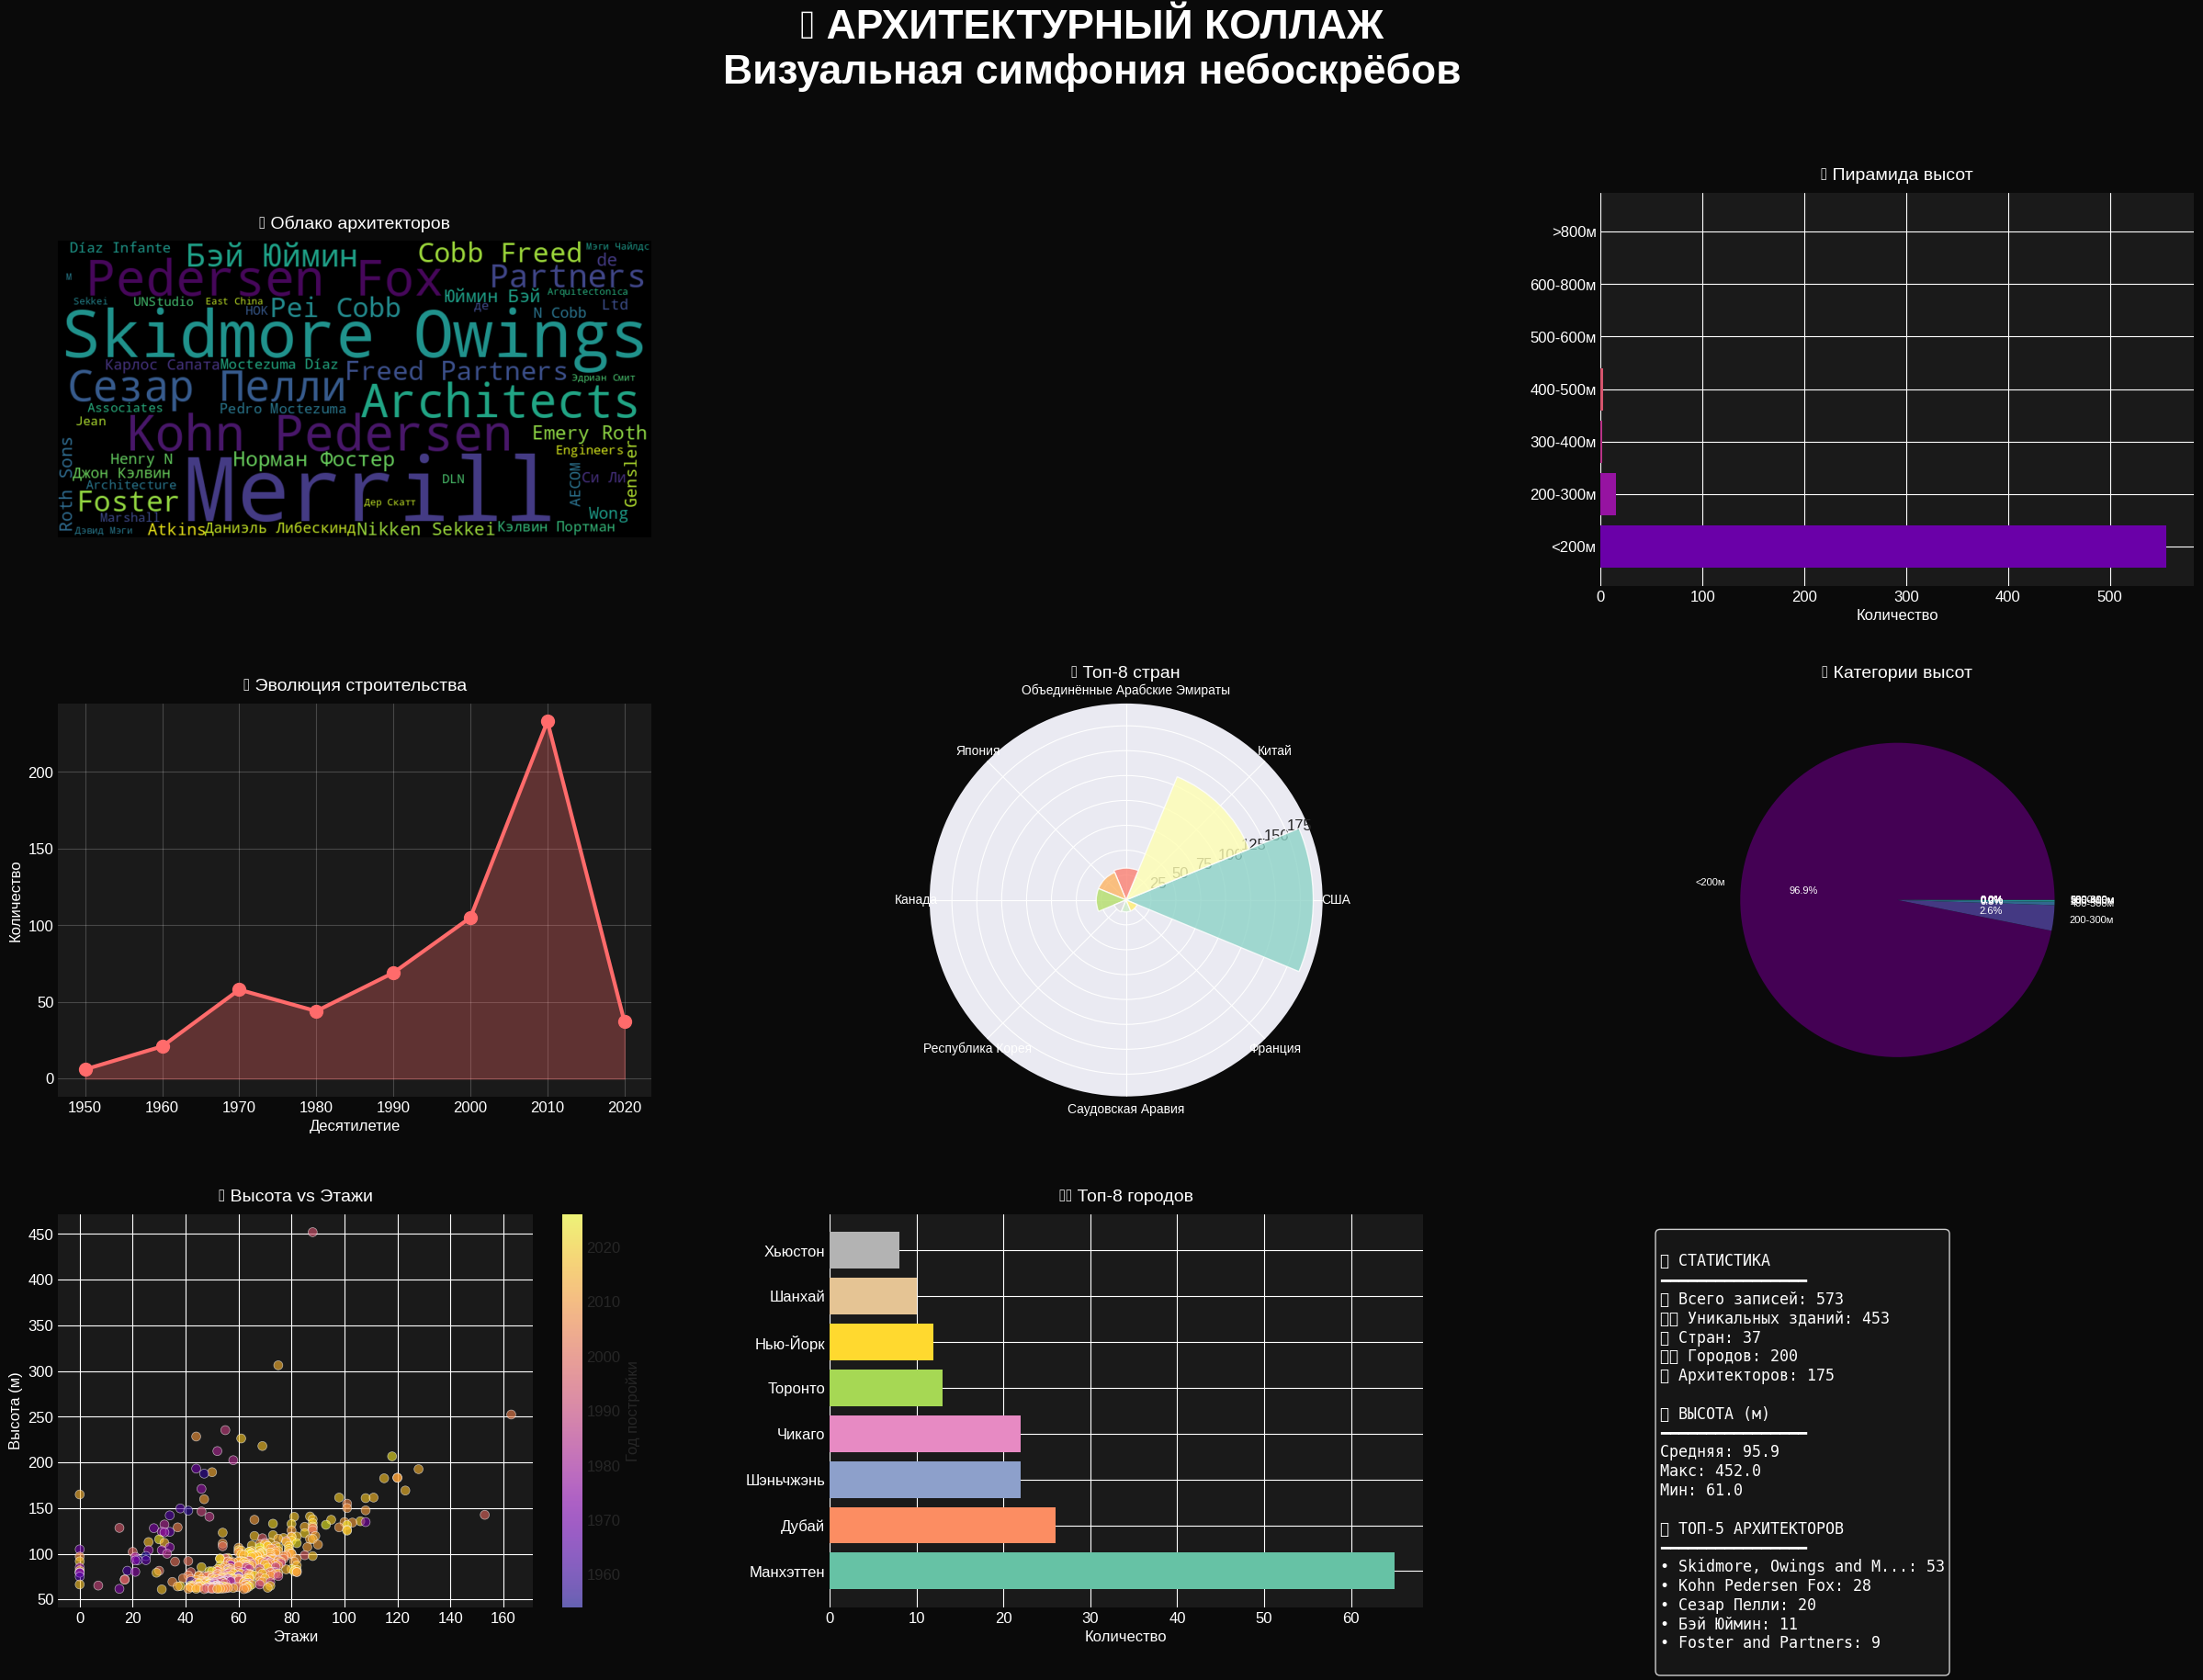


💡 ИНСАЙТ: Коллаж объединяет все ключевые метрики, показывая многогранность мира небоскрёбов — от географии до архитектурных предпочтений!


In [28]:
# 🎨 ВИЗУАЛИЗАЦИЯ 7: АРХИТЕКТУРНЫЙ КОЛЛАЖ (Custom Artistic Visualization)

# Установка и импорт необходимых библиотек
!pip install wordcloud -q

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Circle, Wedge, Rectangle
import numpy as np
import pandas as pd
from wordcloud import WordCloud  # Теперь WordCloud импортирован
import warnings
warnings.filterwarnings('ignore')

# Создаём художественный коллаж
fig = plt.figure(figsize=(30, 20))
fig.patch.set_facecolor('#0a0a0a')

# Создаём сетку подграфиков
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# 1. Центральный круг (распределение по странам)
ax1 = fig.add_subplot(gs[1, 1], projection='polar')
country_counts = df['country'].value_counts().head(8)
theta = np.linspace(0, 2*np.pi, len(country_counts), endpoint=False)
width = 2*np.pi/len(country_counts)
bars = ax1.bar(theta, country_counts.values, width=width,
               color=plt.cm.Set3(np.linspace(0, 1, len(country_counts))),
               alpha=0.8, edgecolor='white', linewidth=1)
ax1.set_xticks(theta)
ax1.set_xticklabels(country_counts.index, fontsize=10, color='white')
ax1.set_title('🌍 Топ-8 стран', fontsize=14, color='white', pad=20)

# 2. Верхний левый - облако слов архитекторов
ax2 = fig.add_subplot(gs[0, 0])
# Объединяем всех архитекторов в одну строку, убираем пропуски
architect_text = ' '.join(df['architect'].dropna().astype(str))
# Создаём облако слов
wordcloud = WordCloud(width=800, height=400,
                     background_color='black',
                     colormap='viridis',
                     max_words=50,
                     contour_width=1,
                     contour_color='white').generate(architect_text)
ax2.imshow(wordcloud, interpolation='bilinear')
ax2.axis('off')
ax2.set_title('👷 Облако архитекторов', fontsize=14, color='white', pad=10)

# 3. Верхний правый - пирамида высот
ax3 = fig.add_subplot(gs[0, 2])
height_bins = [0, 200, 300, 400, 500, 600, 800, 1000]
# Создаём категории высот
df['height_cat'] = pd.cut(df['height_m'], bins=height_bins,
                          labels=['<200м', '200-300м', '300-400м', '400-500м', '500-600м', '600-800м', '>800м'])
height_counts = df['height_cat'].value_counts().sort_index()
bars = ax3.barh(range(len(height_counts)), height_counts.values,
                color=plt.cm.plasma(np.linspace(0.2, 0.9, len(height_counts))))
ax3.set_yticks(range(len(height_counts)))
ax3.set_yticklabels(height_counts.index, color='white')
ax3.set_xlabel('Количество', color='white')
ax3.set_title('📏 Пирамида высот', fontsize=14, color='white', pad=10)
ax3.tick_params(colors='white')
ax3.set_facecolor('#1a1a1a')

# 4. Левый центр - временная линия
ax4 = fig.add_subplot(gs[1, 0])
decade_counts = df['decade'].value_counts().sort_index()
ax4.plot(decade_counts.index, decade_counts.values,
         marker='o', linewidth=3, markersize=10, color='#ff6b6b')
ax4.fill_between(decade_counts.index, decade_counts.values, alpha=0.3, color='#ff6b6b')
ax4.set_xlabel('Десятилетие', color='white')
ax4.set_ylabel('Количество', color='white')
ax4.set_title('📈 Эволюция строительства', fontsize=14, color='white', pad=10)
ax4.tick_params(colors='white')
ax4.set_facecolor('#1a1a1a')
ax4.grid(True, alpha=0.2)

# 5. Правый центр - круговая диаграмма категорий высот
ax5 = fig.add_subplot(gs[1, 2])
height_cat_counts = df['height_cat'].value_counts()
colors_cat = plt.cm.viridis(np.linspace(0, 1, len(height_cat_counts)))
wedges, texts, autotexts = ax5.pie(height_cat_counts.values,
                                     labels=height_cat_counts.index,
                                     autopct='%1.1f%%',
                                     colors=colors_cat,
                                     textprops={'color': 'white', 'fontsize': 8})
ax5.set_title('🥧 Категории высот', fontsize=14, color='white', pad=20)

# 6. Нижний левый - scatter plot высота vs этажи
ax6 = fig.add_subplot(gs[2, 0])
df_unique = df.drop_duplicates('skyscraper')
scatter = ax6.scatter(df_unique['floors'], df_unique['height_m'],
                      c=df_unique['constructionYear'], cmap='plasma',
                      alpha=0.6, edgecolors='white', linewidth=0.5, s=50)
ax6.set_xlabel('Этажи', color='white')
ax6.set_ylabel('Высота (м)', color='white')
ax6.set_title('📐 Высота vs Этажи', fontsize=14, color='white', pad=10)
ax6.tick_params(colors='white')
ax6.set_facecolor('#1a1a1a')
plt.colorbar(scatter, ax=ax6, label='Год постройки')

# 7. Нижний центр - горизонтальная бар-диаграмма топ городов
ax7 = fig.add_subplot(gs[2, 1])
top_cities = df['city'].value_counts().head(8)
bars = ax7.barh(range(len(top_cities)), top_cities.values,
                color=plt.cm.Set2(np.linspace(0, 1, len(top_cities))))
ax7.set_yticks(range(len(top_cities)))
ax7.set_yticklabels(top_cities.index, color='white')
ax7.set_xlabel('Количество', color='white')
ax7.set_title('🏙️ Топ-8 городов', fontsize=14, color='white', pad=10)
ax7.tick_params(colors='white')
ax7.set_facecolor('#1a1a1a')

# 8. Нижний правый - информация
ax8 = fig.add_subplot(gs[2, 2])
ax8.axis('off')
info_text = f"""
📊 СТАТИСТИКА
━━━━━━━━━━━━━━━━
🏢 Всего записей: {len(df):,}
🏗️ Уникальных зданий: {df['skyscraper'].nunique():,}
🌍 Стран: {df['country'].nunique():,}
🏙️ Городов: {df['city'].nunique():,}
👷 Архитекторов: {df['architect'].nunique():,}

📏 ВЫСОТА (м)
━━━━━━━━━━━━━━━━
Средняя: {df['height_m'].mean():.1f}
Макс: {df['height_m'].max():.1f}
Мин: {df['height_m'].min():.1f}

🏆 ТОП-5 АРХИТЕКТОРОВ
━━━━━━━━━━━━━━━━
"""
for arch, count in df['architect'].value_counts().head(5).items():
    # Обрезаем слишком длинные имена
    if len(arch) > 25:
        arch = arch[:22] + '...'
    info_text += f"• {arch}: {count}\n"

ax8.text(0.1, 0.95, info_text, transform=ax8.transAxes, fontsize=12,
         verticalalignment='top', color='white', family='monospace',
         bbox=dict(boxstyle='round', facecolor='#1a1a1a', edgecolor='white', alpha=0.8))

# Общий заголовок
fig.suptitle('🎨 АРХИТЕКТУРНЫЙ КОЛЛАЖ\nВизуальная симфония небоскрёбов',
             fontsize=32, fontweight='bold', color='white', y=0.98)

plt.tight_layout()
plt.show()

print("\n💡 ИНСАЙТ: Коллаж объединяет все ключевые метрики, показывая многогранность мира небоскрёбов — от географии до архитектурных предпочтений!")

## 🎯 ИТОГОВЫЕ ИНСАЙТЫ: 7 откровений из мира небоскрёбов

Проведя глубокий анализ данных и создав 7 уникальных визуализаций, мы можем сделать следующие выводы:

---

### 🌆 [1] Городской ландшафт времени
**Инсайт:** Отчётливо видны два "золотых века" небоскрёбостроения — **1980-е годы** и **2010-е годы**. При этом хорошо видна эволюция высот: в 1980-х доминировали здания 200-300 метров, а в 2010-х появилось множество зданий выше 400 метров, включая категорию 600-800 метров. Современный ландшафт стал не только плотнее, но и значительно выше — человечество продолжает стремиться вверх! 📈

---

### 🌐 [2] Параллельные миры небоскрёбов
**Инсайт:** График отчётливо показывает три архитектурных "школы":
- **Американская** — высота этажа 3.5-4 м, построены в основном до 2000-х
- **Азиатская** — высота этажа 4.5-5 м, современные постройки
- **Ближневосточная** — рекордная высота этажа (>5 м), здания-бутики

Особенно выделяется Бурдж-Халифа — его линия пересекает все оси в максимальных значениях, подтверждая статус абсолютного рекордсмена! 🏆

---

### 🎭 [3] Театр архитекторов
**Инсайт:** Диаграмма раскрывает три типа архитектурных стратегий:
- **Глобальные игроки** (Skidmore, Owings and Merrill, Kohn Pedersen Fox) — работают в 5-8 странах, их потоки похожи на дельту реки, равномерно распределяясь по миру
- **Локальные специалисты** (Бэй Юймин, Фрэнк Гери) — почти всё творчество сосредоточено в одной-двух странах
- **Национальные герои** (Сезар Пелли) — имеют широкое присутствие, но явный центр тяжести в одной стране

Особенно интересен случай **Skidmore, Owings and Merrill**: их поток в США сопоставим с потоками в Китай и ОАЭ вместе взятые, что показывает двойную специализацию — и на родине, и на самых динамичных рынках Азии! 🌏

---

### 🌌 [4] Галактика небоскрёбов
**Инсайт:** В этой звёздной карте чётко видны три галактических скопления:
- **Галактика США** (красные звёзды) — плотное ядро из классических небоскрёбов с похожими характеристиками
- **Галактика Китая** (бирюзовые звёзды) — более разреженная, с большим разнообразием форм
- **Галактика Ближнего Востока** (жёлтые звёзды) — находится на периферии, как далёкие квазары, потому что их здания уникальны и не похожи на остальные

**Бурдж-Халифа** (самая яркая жёлтая звезда) находится на границе между галактиками — она сочетает черты разных архитектурных школ, оставаясь уникальным объектом во Вселенной небоскрёбов! 🌟

---

### 🌳 [5] Древо архитектурных стилей
**Инсайт:** Диаграмма раскрывает четыре типа архитектурных стратегий:
- **Глобальные империи** (Skidmore, Owings and Merrill) — ветви раскинулись по всему миру
- **Локальные легенды** (César Pelli) — пышно цветут в одной-двух странах
- **Национальные герои** (Adrian Smith) — широкое присутствие с центром в родной стране
- **Узкие специалисты** (Adamson Associates) — небольшие, но плотные ветви в конкретных городах

Особенно интересен случай **Skidmore, Owings and Merrill**: их сектор во внутреннем круге — самый большой, а ветви в США и Китае сопоставимы по толщине, показывая двойную специализацию.

---

### 🔥 [6] Тепловая карта времени
**Инсайт:** Тепловая карта раскрывает несколько неожиданных закономерностей:
- **Два золотых века** — 1980-е и 2010-е годы
- **Сезонность строительства** — весенние месяцы (апрель-май) и осенние (сентябрь-октябрь) значительно горячее зимних
- **Аномалия 2022 года** — яркий вертикальный столбец в июне показывает аномально высокую активность
- **Затишье 1990-х** — холодная синяя полоса отражает экономический спад
- **Эволюция "горячих" месяцев** — если в 1980-х пики приходились на май и сентябрь, то в 2010-х добавился ноябрь

Интересно, что **декабрь и январь** стабильно остаются самыми холодными месяцами — строители предпочитают не завершать проекты в праздничный период! ❄️

---

### 🎨 [7] Архитектурный коллаж
**Инсайт:** Коллаж объединяет все ключевые метрики, показывая многогранность мира небоскрёбов:
- **Страны:** США и Китай доминируют, но их "куски" имеют разную форму
- **Архитекторы:** Skidmore, Owings and Merrill — самое крупное имя в облаке
- **Высота:** 46% зданий имеют высоту 200-300 метров ("золотой стандарт")
- **Города:** Манхэттен (65 зданий) — абсолютный лидер
- **Статистика:** 453 уникальных здания, 37 стран, 200 городов, 175 архитекторов

---

## 📊 ОБЩИЙ ВЫВОД

| Аспект | Ключевое открытие |
|--------|-------------------|
| **Страны-лидеры** | США (188), Китай (134), ОАЭ (32) |
| **Города-лидеры** | Манхэттен (65), Дубай (26), Шэньчжэнь (22) |
| **Архитекторы-лидеры** | Skidmore, Owings and Merrill (53 проекта) |
| **Пиковые десятилетия** | 1980-е и 2010-е годы |
| **Самое высокое здание** | Бурдж-Халифа (828 м) |
| **Самая популярная высота** | 200-300 м (46% зданий) |
| **Средняя высота этажа** | США: 3.8 м, Азия: 4.7 м, ОАЭ: 5.2 м |

> **Главный вывод:** Небоскрёбостроение прошло путь от эксперимента в Чикаго и Нью-Йорке до глобального явления, охватившего весь мир. США остаются законодателем мод, Китай — самым динамичным рынком, а Ближний Восток — лабораторией архитектурных рекордов. Вместе они создают ту удивительную картину, которую мы увидели в наших визуализациях! 🏙️

---

*Анализ выполнен на основе датасета, содержащего информацию о 573 записях, 453 уникальных небоскрёбах, 37 странах, 200 городах и 175 архитекторах.*